# Taller4 INF-398 II-2023
**Equipo: MCMC Metropolis**
* Felipe Asbún - 202010509-K - felipe.asbun@usm.cl
* Ignacio Allendes - 202004531-3 - ignacio.allendesm@usm.cl


### **Declaración ética**
Declaramos que el trabajo realizado es original.

**Envíos & Tablero de Resultados:** https://www.kaggle.com/t/3585b66f3fdc4fa289079f2b1a4fe397

El objetivo de esta desafío es que aplique lo aprendido en los últimos capítulos del curso para construir un predictor de precios de automóviles. El problema requiere mucha creatividad de su parte porque se dispone de muy pocos datos de entrenamiento específicos del dominio de interés  pero sí se dispone de una gran cantidad de datos de problemas similares. Esta situación se enfrenta continuamente en la práctica, así es que es bueno ejercitarse con ella.

<table align='left'>
<tr>
<td><img src='https://www.firstvehicleleasing.co.uk/blog/wp-content/uploads/2012/08/Fiat-500-Colour-Therapy.jpg' width='850'/> </td>
</tr>
</table>

# Problema & Datos

 Como se ha anunciado, la particularidad del problema es que usted dispondrá de muchos datos etiquetados de una cierta región geográfica que denominaremos "dominio fuente", pero el objetivo es maximizar la capacidad predictiva en otra zona geográfica, denominada "dominio objetivo", para la cual tienen muy pocos datos. Otra dificultad técnica será que los datos del dominio fuente podrían contener atributos extra.








*   **dominio_fuente_small.csv** - selección. de datos etiquetados del dominio fuente
*   **dominio_fuente.csv** - datos etiquetados del dominio fuente
*   **dominio_objetivo.csv** - datos de entrenamiento del dominio objetivo
*   **x_test.csv** - datos a predecir del dominio objetivo
*   **example_submission.csv** - ejemplo de envío

In [ ]:
!wget www.inf.utfsm.cl/~jnancu/dominio_objetivo.csv
!wget www.inf.utfsm.cl/~jnancu/dominio_fuente_small.
!wget www.inf.utfsm.cl/~jnancu/x_test.csv
!wget www.inf.utfsm.cl/~jnancu/example_submission.csv
!wget www.inf.utfsm.cl/~jnancu/dominio_fuente.csv

--2023-11-28 21:06:52--  http://www.inf.utfsm.cl/~jnancu/dominio_objetivo.csv
Resolving www.inf.utfsm.cl (www.inf.utfsm.cl)... 200.1.19.11, 2800:270:c::11
Connecting to www.inf.utfsm.cl (www.inf.utfsm.cl)|200.1.19.11|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.inf.utfsm.cl/~jnancu/dominio_objetivo.csv [following]
--2023-11-28 21:06:52--  https://www.inf.utfsm.cl/~jnancu/dominio_objetivo.csv
Connecting to www.inf.utfsm.cl (www.inf.utfsm.cl)|200.1.19.11|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11266 (11K) [application/octet-stream]
Saving to: ‘dominio_objetivo.csv’

dominio_objetivo.cs 100%[===================>]  11.00K  --.-KB/s    in 0s      

2023-11-28 21:06:53 (125 MB/s) - ‘dominio_objetivo.csv’ saved [11266/11266]

URL transformed to HTTPS due to an HSTS policy
--2023-11-28 21:06:53--  https://www.inf.utfsm.cl/~jnancu/dominio_fuente_small.
Resolving www.inf.utfsm.cl (www.inf.utfsm.cl)... 200.1.19.11, 280

Como ejemplo de la diferencia, considere que los precios del dominio objetivo tienen una media de alrededor de 14500 USD, mientras que los precios del dominio fuente tienen una media de alrededor de 15062 USD.

# Mínimos Esperados

*   La solución debe comparar al menos 2 alternativas de solución y elegir una de ellas.

*   La solución debe ir acompañada de una estimación del error de la solución elegida.

*   La solución debe incluir una propuesta para usar los datos del dominio fuente con el objetivo de mejorar las predicciones del dominio objetivo.

# Solución

## Imports

In [ ]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns; sns.set()
import matplotlib.pyplot as plt
import xgboost

# Set ggplot styles and update Matplotlib with them.
ggplot_styles = {
    'axes.grid': False
}

plt.rcParams.update(ggplot_styles)

import warnings; warnings.filterwarnings("ignore")
plt.rcParams.update({'font.size': 8})
plt.rc('xtick',labelsize=8)
plt.rc('ytick',labelsize=8)
plt.rc('axes', labelsize=8)
plt.rc('legend',fontsize=10)

## Carga de Datos

In [ ]:
cols=['ID','name', 'year', 'mileage', 'engine', 'transmission', 'age', 'price']
dominio_objetivo = pd.read_csv('dominio_objetivo.csv')
print(dominio_objetivo.shape)
print(dominio_objetivo.columns)
print(dominio_objetivo.head(5))
dominio_objetivo['engine'].unique()

(205, 8)
Index(['ID', 'name', 'year', 'mileage', 'engine', 'transmission', 'age',
       'price'],
      dtype='object')
     ID                           name  year  mileage  engine   transmission  \
0   421                    nissan juke  2019    16715  Petrol      Automatic   
1   403                   renault clio  2017    47500  Petrol         Manual   
2  2757                  ford ecosport  2018    14102  Petrol  Semiautomatic   
3   998  land rover range rover evoque  2017    36238  Diesel      Automatic   
4  1944                    ford fiesta  2011    90000  Petrol         Manual   

   age    price  
0    4  14295.0  
1    6   7995.0  
2    5  14400.0  
3    6  24950.0  
4   12   3195.0  


array(['Petrol', 'Diesel', 'Hybrid'], dtype=object)

In [ ]:
small = False
if small:
    dominio_fuente = pd.read_csv('dominio_fuente_small.csv')
else:
    dominio_fuente = pd.read_csv('dominio_fuente.csv')

print(dominio_fuente.shape)
print(dominio_fuente.columns)
print(dominio_fuente.head(5))

(388319, 20)
Index(['Unnamed: 0', 'id', 'price', 'year', 'manufacturer', 'model',
       'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'drive', 'size', 'type', 'paint_color', 'state', 'lat',
       'long', 'FILTER'],
      dtype='object')
   Unnamed: 0          id      price  year manufacturer  \
0          27  7316814884  32105.322  2014          gmc   
1          28  7316814758  21591.521  2010    chevrolet   
2          29  7316814989  37840.120  2020    chevrolet   
3          30  7316743432  29620.242  2017       toyota   
4          31  7316356412  14337.000  2013         ford   

                      model  condition    cylinders fuel  odometer  \
0  sierra 1500 crew cab slt       good  8 cylinders  gas   57923.0   
1            silverado 1500       good  8 cylinders  gas   71229.0   
2       silverado 1500 crew       good  8 cylinders  gas   19160.0   
3      tundra double cab sr       good  8 cylinders  gas   41124.0   
4                

In [ ]:
col_xtest =['ID','name', 'year', 'mileage', 'engine', 'transmission', 'age']
x_test = pd.read_csv('x_test.csv')
print(x_test.shape)
print(x_test.columns)
print(x_test.head(5))

(1846, 7)
Index(['ID', 'name', 'year', 'mileage', 'engine', 'transmission', 'age'], dtype='object')
     ID                  name  year mileage  engine   transmission  age
0  2794         ford ecosport  2018   19512  Petrol         Manual    5
1  1520       mini countryman  2014   56502  Petrol         Manual    9
2   936          toyota yaris  2017    1302  Petrol         Manual    6
3  2523  mitsubishi outlander  2014   53658  Diesel  Semiautomatic    9
4  1407           ford fiesta  2011  104000  Diesel         Manual   12


## Edad del Automóvil

In [ ]:
collection_year_source = 2021
dominio_fuente['age'] = collection_year_source - dominio_fuente['year']
dominio_fuente['age'] = dominio_fuente['age'].astype(np.float32)

## Limpieza de datos

In [ ]:
dominio_objetivo['name'] = dominio_objetivo['name'].str.replace('land rover', 'land-rover')
dominio_objetivo[['manufacturer', 'model']] = dominio_objetivo['name'].str.split(n=1, expand=True)
dominio_objetivo = dominio_objetivo.drop(columns=['name'])

x_test['name'] = x_test['name'].str.replace('land rover', 'land-rover')
x_test[['manufacturer', 'model']] = x_test['name'].str.split(n=1, expand=True)
x_test = x_test.drop(columns=['name'])
# Limpiar el x_test
#Cambiamos las filas susy
x_test.loc[lambda x: x['engine']=='Manual']=[1137,2013,0,'Diesel','Manual',10,'bmw','1 series']
x_test.loc[lambda x: x['engine']=='Automatic']=[1795,2018,0,'No sabe','Automatic',5,'bmw','3 series']
#cambiamos Plug_in_hybrid por Hybrid
x_test['engine'] = x_test['engine'].str.replace('Plug_in_hybrid', 'Hybrid')
#Procesar El xtest
ids = x_test['ID']

x_test=x_test.drop(['ID'],axis=1)
x_test['mileage'] = x_test['mileage'].astype(float)
x_test['mileage'] = x_test['mileage'].fillna(x_test['mileage'].mean())

x_test['zona']=1


cols_para_drop = ['Unnamed: 0','condition','cylinders','title_status','drive','size','type','paint_color','state','lat','long','FILTER']

dominio_fuente=dominio_fuente.drop(cols_para_drop,axis=1)
dominio_fuente['manufacturer'] = dominio_fuente['manufacturer'].str.replace('land rover', 'land-rover')
dominio_fuente['fuel'] = dominio_fuente['fuel'].str.replace('gas', 'Petrol')
dominio_fuente['fuel'] = dominio_fuente['fuel'].str.replace('diesel', 'Diesel')
dominio_fuente['fuel'] = dominio_fuente['fuel'].str.replace('hybrid', 'Hybrid')
dominio_fuente['fuel'] = dominio_fuente['fuel'].str.replace('electric', 'Electric')
dominio_fuente['transmission'] = dominio_fuente['transmission'].str.replace('automatic', 'Automatic')
dominio_fuente['transmission'] = dominio_fuente['transmission'].str.replace('manual', 'Manual')
dominio_fuente['transmission'] = dominio_fuente['transmission'].str.replace('other', 'Semiautomatic') #Bajo el supuesto other==Semiauto
# Eliminar las filas con 'other', 'electric' y NaN en la columna 'fuel'
dominio_fuente = dominio_fuente[(dominio_fuente['fuel'] != 'other')  & ~dominio_fuente['fuel'].isna()]
dominio_fuente = dominio_fuente.rename(columns={'fuel': 'engine'})
#eliminar precios ==0
dominio_fuente= dominio_fuente[lambda x: x['price']!=0]
#escalara kilometraje a millaje
dominio_fuente['odometer']=0.621371*dominio_fuente['odometer']
dominio_fuente = dominio_fuente.rename(columns={'odometer': 'mileage'})
#quitamos kilometrajes muy grandes
mil_max=dominio_objetivo['mileage'].max()
dominio_fuente=dominio_fuente[lambda x: x['mileage']<=mil_max]
# potente
dominio_fuente = dominio_fuente[dominio_fuente['manufacturer'].isin(dominio_objetivo['manufacturer'])]
dominio_fuente = dominio_fuente[dominio_fuente['model'].isin(dominio_objetivo['model'])]
dominio_fuente = dominio_fuente.drop(['id'],axis=1)

In [ ]:
#¿dominio_objetivo y x_test comparten manufacturer y model?
#R: sí
array1=dominio_objetivo['manufacturer'].unique()
array2=x_test['manufacturer'].unique()
print(np.isin(array1,array2))
print(np.isin(array2,array1))
array1=dominio_objetivo['model'].unique()
array2=x_test['model'].unique()
print(np.isin(array1,array2))
print(np.isin(array2,array1))

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True]
[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True

In [ ]:
from sklearn.model_selection import train_test_split
#unamos los datasets atemporales Idea: Añadir una columna sobre zona geografica
dominio_objetivo=dominio_objetivo.drop(['ID'],axis=1)


#añadir columna zona 0 es fuente y zona 1 es objetivo
dominio_fuente['zona']=0
dominio_objetivo['zona']=1


dominio_objetivo_train,dominio_objetivo_test,__,__ = train_test_split(dominio_objetivo,  np.zeros(dominio_objetivo.shape[0]))
#combinasao
new_dominio=pd.concat([dominio_fuente,dominio_objetivo_train])

## Visualización de datos

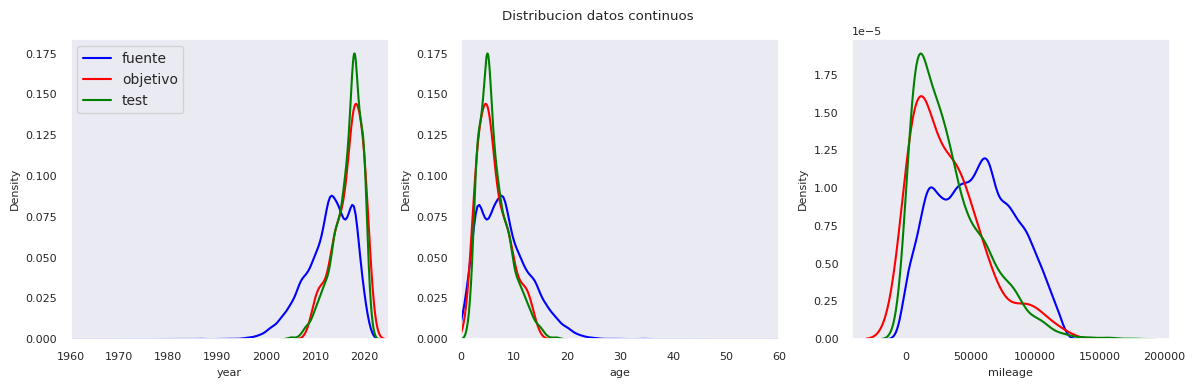

In [ ]:

continuous_features = ['year', 'age', 'mileage']


fig, ax = plt.subplots(figsize=(12,4), nrows=1, ncols=len(continuous_features))

for i, col in enumerate(continuous_features):
    sns.kdeplot(new_dominio.loc[new_dominio['zona']==0], x=col, ax=ax[i], color='blue', label='fuente')
    sns.kdeplot(new_dominio.loc[new_dominio['zona']==1], x=col, ax=ax[i], color='red', label='objetivo')
    sns.kdeplot(x_test, x=col, ax=ax[i], color='green', label='test')
ax[0].legend()
ax[0].set_xlim(left=1960, right=2025)
ax[1].set_xlim(left=0, right=60)
if small:
    ax[2].set_xlim(left=-0.01*10**7, right=0.07*10**7)
fig.suptitle('Distribucion datos continuos', y=0.95)
fig.tight_layout()
plt.show()

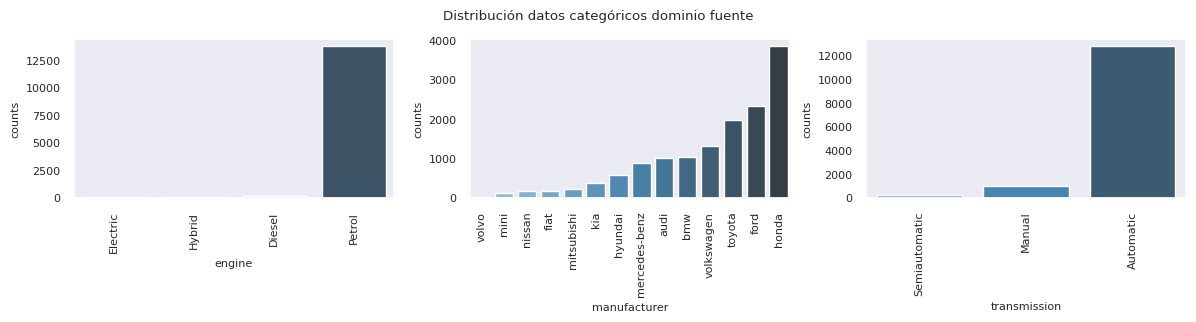

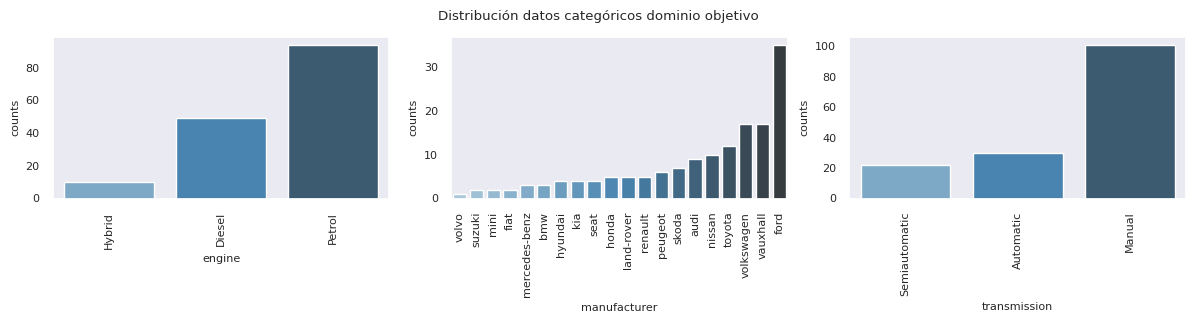

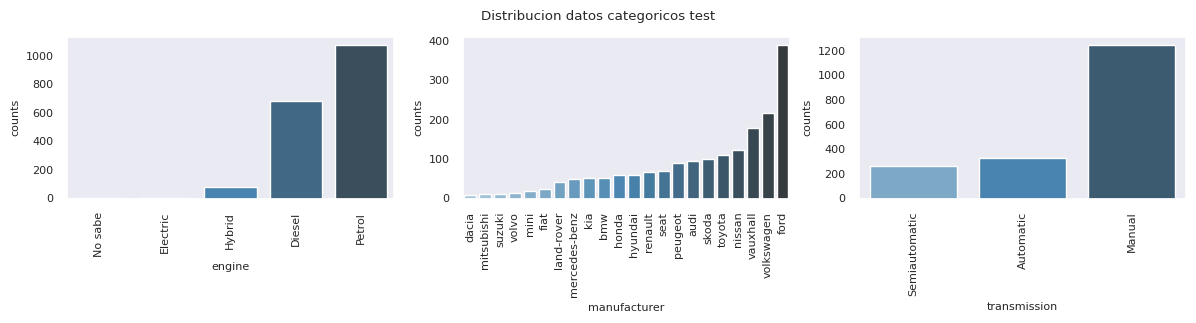

In [ ]:
categorical_features = ['engine', 'manufacturer', 'transmission']
fig, axes = plt.subplots(figsize=(12,3), nrows=1, ncols=len(categorical_features))
for i, column in enumerate(categorical_features):
    df_gb = (new_dominio.loc[new_dominio['zona']==0]).groupby([column]).size().reset_index(name='counts')
    df_gb = df_gb.sort_values(by='counts')
    sns.barplot(data=df_gb, y='counts', x=column, palette="Blues_d",ax=axes[i])
    axes[i].tick_params(axis='x', labelrotation=90)
fig.tight_layout()
fig.suptitle('Distribución datos categóricos dominio fuente', y=1.05)

fig, axes = plt.subplots(figsize=(12,3), nrows=1, ncols=len(categorical_features))
for i, column in enumerate(categorical_features):
    df_gb = new_dominio.loc[new_dominio['zona']==1].groupby([column]).size().reset_index(name='counts')
    df_gb = df_gb.sort_values(by='counts')
    sns.barplot(data=df_gb, y='counts', x=column, palette="Blues_d",ax=axes[i])
    axes[i].tick_params(axis='x', labelrotation=90)
fig.tight_layout()
fig.suptitle('Distribución datos categóricos dominio objetivo', y=1.05)

fig, axes = plt.subplots(figsize=(12,3), nrows=1, ncols=len(categorical_features))
for i, column in enumerate(categorical_features):
    df_gb = x_test.groupby([column]).size().reset_index(name='counts')
    df_gb = df_gb.sort_values(by='counts')
    sns.barplot(data=df_gb, y='counts', x=column, palette="Blues_d",ax=axes[i])
    axes[i].tick_params(axis='x', labelrotation=90)
fig.tight_layout()
fig.suptitle('Distribucion datos categoricos test', y=1.05)


plt.show()

## Encoding

In [ ]:
#Encodificar
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

df = new_dominio.drop('price',axis=1)

# Especifica las columnas a las que deseas aplicar OneHotEncoder
columnas_onehot = ['manufacturer', 'model','engine','transmission']

# Crea un ColumnTransformer para aplicar OneHotEncoder solo a las columnas seleccionadas
transformador = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), columnas_onehot),
        ('minmax', MinMaxScaler(), continuous_features)],
    remainder='passthrough'
)
new_dominio_transform = pd.DataFrame(transformador.fit_transform(df), columns=transformador.get_feature_names_out(df.columns),index=new_dominio.index)
x_test_transform = pd.DataFrame(transformador.transform(x_test), columns=transformador.get_feature_names_out(df.columns))

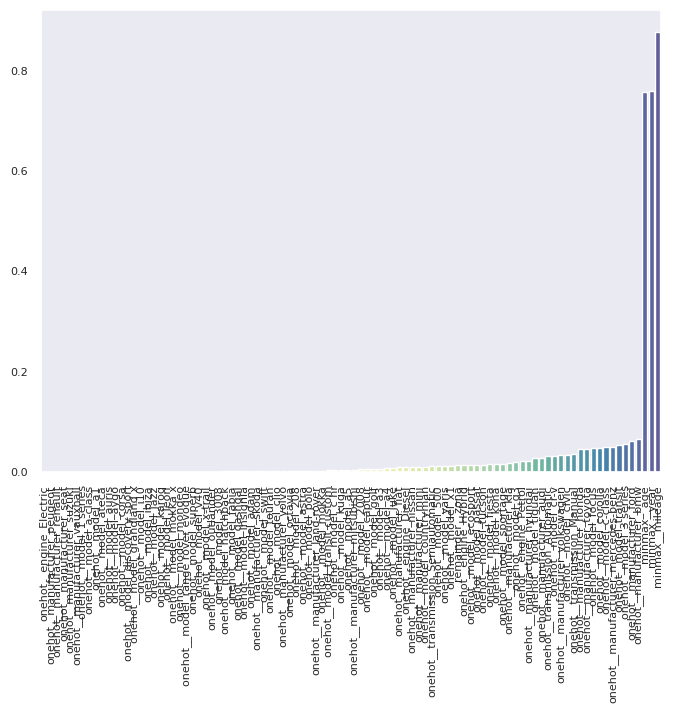

In [ ]:
from sklearn.feature_selection import mutual_info_regression
x_train = pd.concat([dominio_fuente, dominio_objetivo])
y_train = x_train['price']
x_train = (pd.DataFrame( transformador.transform(x_train), columns=transformador.get_feature_names_out(df.columns)))

mi = mutual_info_regression(x_train, y_train, n_neighbors=10)

fig, axes = plt.subplots(figsize=(8,6), nrows=1, ncols=1)
plot_data=[]
for i, m in enumerate(mi):
    for j, x in enumerate(x_train.columns):
        if i == j:
            plot_data.append((m, x))
plot_data.sort()

plot_data = {'x': [plot_data[i][1] for i,_ in enumerate(plot_data)], 'y': [plot_data[i][0] for i,_ in enumerate(plot_data)]}
p = sns.barplot(data=plot_data,x='x', y='y', palette="Spectral",ax=axes)
plt.xticks(rotation=90)
plt.show()

# Primera alternativa

## Training

In [ ]:
#Usar SMOTEEN para balancear las zonas
from imblearn.combine import SMOTEENN
new_dominio_transform['price']=new_dominio['price']
smoteenn = SMOTEENN(random_state=42)
X_smoteenn, y_smoteenn = smoteenn.fit_resample(new_dominio_transform.drop('remainder__zona',axis=1),new_dominio_transform['remainder__zona'])

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error as mape
X_smoteenn['remainder__zona']=y_smoteenn
grad=GradientBoostingRegressor(n_estimators=10000,learning_rate=0.001,max_depth=4) #n_estimators=10000,learning_rate=0.001,max_depth=9
X_Train = X_smoteenn.drop('price',axis=1)
y_Train = X_smoteenn['price']

X_train,X_test,y_train,y_test=train_test_split(X_Train,y_Train,test_size=0.1)

grad.fit(X_train,y_train)
print('r2 train:',grad.score(X_train,y_train))
print('mape train:',mape(y_train,grad.predict(X_train)))
print('r2 test:',grad.score(X_test,y_test))
print('mape test:',mape(y_test,grad.predict(X_test)))

r2 train: 0.851293699694878
mape train: 24.27624209243333
r2 test: 0.8349657464344201
mape test: 48.916817682117916


## Error de predicción

In [ ]:
#Revisemos el score en el dominio_fuente_test
X_obj_test =  pd.DataFrame(transformador.transform(dominio_objetivo_test.drop('price',axis=1)), columns=transformador.get_feature_names_out(df.columns))
y_obj_test = dominio_objetivo_test['price']
print('r2 en datos del objetivo no vistos:',grad.score(X_obj_test,y_obj_test))
print('mape en datos del objetivo no vistos',mape(y_obj_test,grad.predict(X_obj_test)))

r2 en datos del objetivo no vistos: 0.7440952691214959
mape en datos del objetivo no vistos 0.19729754621635529


# Segunda Alternativa

## Predictor en el fuente

In [ ]:
from sklearn.ensemble import RandomForestRegressor
fuente_transform = pd.DataFrame(transformador.transform(dominio_fuente.drop('price',axis=1)), columns=transformador.get_feature_names_out(df.columns),index=dominio_fuente.index)
X_fuente_train,X_fuente_test,y_fuente_train,y_fuente_test = train_test_split(fuente_transform,dominio_fuente['price'],test_size=0.1)
predictor2 = RandomForestRegressor(n_estimators=10000,max_depth=30)
predictor2.fit(X_fuente_train,y_fuente_train)
print('r2 train:',predictor2.score(X_fuente_train,y_fuente_train))
print('mape train:',mape(y_fuente_train,predictor2.predict(X_fuente_train)))
print('r2 test:',predictor2.score(X_fuente_test,y_fuente_test))
print('mape test:',mape(y_fuente_test,predictor2.predict(X_fuente_test)))

r2 train: 0.9723772373989352
mape train: 11.334109006182256
r2 test 0.8130429672552235
mape test 54.39166471989936


## Predictor en el objetivo

In [ ]:
X_obj = pd.DataFrame(transformador.transform(dominio_objetivo.drop('price',axis=1)), columns=transformador.get_feature_names_out(df.columns),index=dominio_objetivo.index)
y_obj=dominio_objetivo['price']
X_Obj_train,X_Obj_test,y_Obj_train,y_Obj_test=train_test_split(X_obj,y_obj,test_size=0.1)
predictor1=GradientBoostingRegressor(n_estimators=10000,learning_rate=0.002,max_depth=1)
predictor1.fit(X_Obj_train,y_Obj_train)
print('r2 train:',predictor1.score(X_Obj_train,y_Obj_train))
print('mape train:',mape(y_Obj_train,predictor1.predict(X_Obj_train)))
print('r2 test:',predictor1.score(X_Obj_test,y_Obj_test))
print('mape test:',mape(y_Obj_test,predictor1.predict(X_Obj_test)))

0.8936700592817894
0.1652320919636781
0.7991093914528802
0.17058731345530104


## Regresor final

In [ ]:
predicciones_Obj_train=np.array([predictor2.predict(X_Obj_train),predictor1.predict(X_Obj_train)]).T
predicciones_Obj_test=np.array([predictor2.predict(X_Obj_test),predictor1.predict(X_Obj_test)]).T
reg=GradientBoostingRegressor(n_estimators=10000,learning_rate=0.001,max_depth=1)
reg.fit(predicciones_Obj_train,y_Obj_train)
print('r2 train:',reg.score(predicciones_Obj_train,y_Obj_train))
print('mape train:',mape(y_Obj_train,reg.predict(predicciones_Obj_train)))
print('r2 test:',reg.score(predicciones_Obj_test,y_Obj_test))
print('mape test:',mape(y_Obj_test,reg.predict(predicciones_Obj_test)))

r2 train: 0.931827242304446
mape train: 0.1288391291251935
r2 test: 0.8119705454257209
mape test: 0.16217075884502793


## Submission

In [ ]:
#primera alternativa
y_pred_1 = grad.predict(x_test_transform)
y_pred_1

array([14921.0500796 ,  7591.13008741, 10926.33331252, ...,
       15632.86241722, 23648.80448208,  9821.11437483])

In [ ]:
#segunda alternativa
predicciones_en_test = np.array([predictor2.predict(x_test_transform),predictor1.predict(x_test_transform)]).T
y_pred_2 = reg.predict(predicciones_en_test)

In [ ]:
submission_1 = pd.DataFrame({'ID':ids,'TARGET':y_pred_1})
submission_2 = pd.DataFrame({'ID':ids,'TARGET':y_pred_2})

In [ ]:
submission_1.to_csv('submission_alternativa_1.csv',index=False)
submission_2.to_csv('submission_alternativa_2.csv',index=False)